# Auto-immune dataset - Milo differential abundance analysis example

Example workflows for more details:

- [Milopy vignette](https://nbviewer.org/github/emdann/milopy/blob/master/notebooks/milopy_example.ipynb)
- [Extended milo example](https://github.com/Teichlab/scripts/blob/main/conditions/extended_milopy_example.ipynb)

In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc


In [2]:
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [3]:
print(sc.__version__)

1.9.1


In [4]:
import milopy.core as milo
import milopy

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import sc_toolbox

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

### Load integrated dataset

In [6]:
def load_sub_adata(adata, obs_file):
    obs = pd.read_csv(obs_file, index_col=0)
    if "scvi_clusters" in obs.columns:
        obs.drop(columns="scvi_clusters", inplace=True)
    temp = adata[obs.index].copy()
    temp.obs = obs
    return temp

def load_scvi_outs(adata, emb_file):
    X_scVI_emb = np.load(emb_file)
    X_scVI_umap = np.load(emb_file.rstrip("_scANVI.scVI_out.npy") + "_scANVI.UMAP.npy")
    #X_scVI_clust = pd.read_csv(emb_file.rstrip("_scANVI.scVI_out.npy") + "_scANVI.clustering.csv", index_col=0)
    adata.obsm["X_scANVI"] = X_scVI_emb
    adata.obsm["X_umap"] = X_scVI_umap
    #adata.obs["scvi_clusters"] = X_scVI_clust.loc[adata.obs_names]["leiden_1_5"].astype("category")

In [7]:
adata_query = sc.read_h5ad('/nfs/team205/bh14/Datasets/Remapped/raw_adata/ummapped/PBMC/adata_query_PBMC_integrated.h5ad')
adata_ref = sc.read_h5ad("/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Myeloid_From_PBMC_Subset_annotated_2.h5ad")


In [8]:
adata_query = adata_query[adata_query.obs.leiden_1_5.isin(['16', '21', '14', '19', '23', '4', '2', '8', '11'])].copy()

In [9]:
adata = adata_query.concatenate(adata_ref)

In [10]:
adata

AnnData object with n_obs × n_vars = 247307 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'cell_type', 'CD3_14_bool'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0-0-0-0', 'feature_name-1-0-0-0-0', 'feature_reference-1-0-0-0-0',

In [6]:
dir_save="/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/"

In [12]:
obs = pd.read_csv(dir_save+"scANVI_Myeloid_cells_out/Myeloid_cell_from_PBMC_scANVI.obs.csv",
                 index_col=0)

In [13]:
load_scvi_outs(adata, emb_file=dir_save+"scANVI_Myeloid_cells_out/Myeloid_cell_from_PBMC_scANVI.scVI_out.npy")


In [14]:
adata.obs = pd.DataFrame(obs)

In [15]:
adata.obs

,tissue,disease,donor_id,dataset_id,cell_source,doublet_scores,predicted_doublets,n_genes_by_counts,total_counts,total_counts_mt,...,conf_score,leiden_0_7,leiden_0_5,leiden_0_6,leiden_man,leiden_R,CD3_14_bool,leiden,predictions,Cell_type_scANVI
AAAGTAGTCCGAATGT-1_0_0_0_0-0,Blood,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022,PBMC,0.017114,False,1902,7949.0,207.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,cMon 2,cMon 2
AAAGTAGTCCGCAAGC-1_0_0_0_0-0,Blood,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022,PBMC,0.105870,False,1091,2808.0,78.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Non-cMon,Non-cMon
AAATGCCTCTGAGGGA-1_0_0_0_0-0,Blood,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022,PBMC,0.023136,False,740,1971.0,149.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,cMon 3,cMon 3
AACACGTGTTGTACAC-1_0_0_0_0-0,Blood,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022,PBMC,0.081299,False,1213,3910.0,72.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,cMon 1,cMon 1
AACACGTTCCACGTGG-1_0_0_0_0-0,Blood,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022,PBMC,0.035610,False,2030,7250.0,148.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,cMon 1,cMon 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Run20956_lane8_106_1-1,Blood,Healthy,ARMS005,Braga_asthma_CD4,Blood_CD4,0.306567,False,1763,413031.0,12798.0,...,0.995136,7.0,5.0,6.0,"6,0","6,0",False,7,CD3+CD14+?,cMon 3
Run22167_lane6_239_1-1,Blood,Asthma,ARMS015,Braga_asthma_CD4,Blood_CD4,0.167005,False,629,225796.0,3298.0,...,0.999701,7.0,5.0,6.0,"6,0","6,0",False,11,CD3+CD14+?,cMon 4
Run23847_lane6_256_1-1,Blood,Asthma,ARMS024,Braga_asthma_CD4,Blood_CD4,0.080658,False,1198,295573.0,9306.0,...,0.966709,6.0,4.0,5.0,5,5,False,11,Megakaryocytes/platelets,cMon 4
Run20956_lane8_7_1-1,Blood,Healthy,ARMS004,Braga_asthma_CD4,Blood_CD4,0.219375,False,2144,240909.0,10612.0,...,0.997980,7.0,5.0,6.0,"6,1","6,1",False,11,Megakaryocyte precursor,cMon 4


In [16]:
del adata_query
del adata_ref

In [17]:
adata

AnnData object with n_obs × n_vars = 247307 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'CD3_14_bool', 'leiden', 'predictions', 'Cell_type_scANVI'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'feature_is_f

In [18]:
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=60, use_rep="X_scANVI", key_added="scvi_neighbors")


In [19]:
sc.tl.umap(adata, min_dist=0.7, neighbors_key='scvi_neighbors', spread=2)

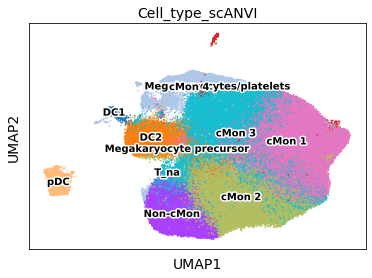

In [9]:
sc.set_figure_params(figsize=(9,9))
sc.pl.umap(
    adata,
    color=["Cell_type_scANVI"],
    ncols=2,
    frameon=True,
    size=10,
    legend_fontoutline=3,
    legend_fontsize=10,
    legend_loc="on data",
    cmap='OrRd'

)

In [21]:
adata.obs.dataset_id.value_counts(dropna=False)

Perez_2022                     212682
Qian_Yue_Zhang_2022             13591
GSE163314_Lefferts_2021          8122
GSE157278_Hong_2020              6664
Martin_JIA_2019                  3229
GSE134809_Martin_et_al_2019      2990
Braga_asthma_CD4                   19
E-MTAB-9492_Penkava_2020           10
Name: dataset_id, dtype: int64

In [22]:
del adata.obs["CD3_14_bool"]

In [23]:
adata = adata[-adata.obs.dataset_id.isin(['Braga_asthma_CD4', 'E-MTAB-9492_Penkava_2020'])]

In [24]:
adata.shape

(247278, 20301)

We remove an unknown cluster that expresses CD3

In [11]:
adata[adata.obs.Cell_type_scANVI=="T_na"].shape

(6, 20301)

In [12]:
adata = adata[adata.obs.Cell_type_scANVI!="T_na"]

In [7]:
#adata.write_h5ad(dir_save+"scANVI_Myeloid_cells_out/Myeloid_cell_from_PBMC_scANVI.h5ad")

adata = sc.read_h5ad(dir_save+"scANVI_Myeloid_cells_out/Myeloid_cell_from_PBMC_scANVI.h5ad")


We will keep only donors with average 10 cells in each cluster

In [8]:
adata.shape

(247272, 20301)

In [9]:
ncel = len(adata.obs.Cell_type_scANVI.unique())

In [10]:
size_by_donor = adata.obs.groupby(["donor_id"]).size()

In [11]:
donors_to_keep = [
    donor
    for donor in size_by_donor.index
    if size_by_donor[donor] >= 10*ncel
]

In [12]:
len(donors_to_keep)

289

In [13]:
len(adata.obs.donor_id.unique())

293

In [14]:
donors_to_keep[:10]

['0a0c1c97-6ee8-4ac7-acc0-298fe1f45bc5',
 '0e976519-2477-4e53-bb3a-4322ee2ec163',
 '1a80b7d3-dd95-4b5a-bb30-33b17b3ead13',
 '1bed79e5-39d1-461e-a189-7a70e95b250d',
 '1c2ab600-edb3-476b-a335-e82a639cc01b',
 '1d0c9aa0-f3e6-4c13-be75-73a7fd61338b',
 '1d8daffc-3a35-4d5c-95e3-0ef93ef6a90c',
 '1d15a70f-8b4c-4d49-a08b-c7098cd3b170',
 '1d64c1cf-4e1e-4e4f-beca-c3a4df36fdcf',
 '1f29e6e0-accc-469c-97e3-4b66613fac9a']

In [15]:
adata = adata[adata.obs["donor_id"].isin(donors_to_keep)]

In [16]:
adata.shape

(247067, 20301)

In [17]:
adata.obs.disease.value_counts()

Systemic lupus erythematosus    111051
Healthy                         105928
Hashimoto’s thyroiditis          13590
Crohn's Disease                   5957
Sjögren’s syndrome                3841
Oligoarticular JIA                3229
Spondyloarhtritis                 3048
CD + Spondyloarthritis             423
Name: disease, dtype: int64

In [18]:
gc.collect()

71

In [8]:
sample_cols = ['dataset_id', 'donor_id', 'tissue', 'disease', 'cell_source', 'Cell_type_scANVI']
sample_df = adata.obs[sample_cols].groupby(sample_cols).size().reset_index()
sample_df.columns = sample_cols + ['n_cells']
sample_df = sample_df[sample_df['n_cells'] > 0].copy()
sample_df

,dataset_id,donor_id,tissue,disease,cell_source,Cell_type_scANVI,n_cells
10504,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,DC1,2
10505,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,DC2,31
10506,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,Non-cMon,15
10507,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,cMon 1,191
10508,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,cMon 2,39
...,...,...,...,...,...,...,...
103827,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,cMon 1,150
103828,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,cMon 2,54
103829,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,cMon 3,383
103830,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,cMon 4,2414


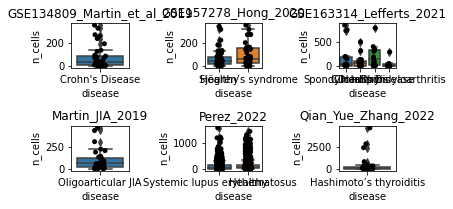

In [9]:
all_datasets = sample_df['dataset_id'].unique()
all_diseases = sample_df['disease'].unique()

with plt.rc_context({'figure.figsize':[15,10]}):
    for i,d in enumerate(all_datasets):
        plt.subplot(3,3,i+1);
        d_df = sample_df[sample_df.dataset_id == d].copy()
        d_df['disease'] = d_df['disease'].astype('str')
        sns.boxplot(
            data = d_df,
            x = 'disease',
            y = 'n_cells'
        );
        sns.stripplot(
            data = d_df,
            x = 'disease',
            y = 'n_cells',
            color = 'black'
        );
        plt.title(d);
    plt.tight_layout()
    plt.show()

Check sample metadata

In [10]:
all_diseases

['Crohn's Disease', 'Healthy', 'Sjögren’s syndrome', 'Spondyloarhtritis', 'CD + Spondyloarthritis', 'Oligoarticular JIA', 'Systemic lupus erythematosus', 'Hashimoto’s thyroiditis']
Categories (8, object): ['CD + Spondyloarthritis', 'Crohn's Disease', 'Hashimoto’s thyroiditis', 'Healthy', 'Oligoarticular JIA', 'Sjögren’s syndrome', 'Spondyloarhtritis', 'Systemic lupus erythematosus']

In [11]:
sample_df['disease'].value_counts()

Systemic lupus erythematosus    1161
Healthy                          805
Crohn's Disease                   54
Sjögren’s syndrome                39
Oligoarticular JIA                32
Hashimoto’s thyroiditis           31
Spondyloarhtritis                 16
CD + Spondyloarthritis             8
Name: disease, dtype: int64

In [12]:
adata.obs.disease.unique()

['Hashimoto’s thyroiditis', 'Systemic lupus erythematosus', 'Healthy', 'Oligoarticular JIA', 'Crohn's Disease', 'CD + Spondyloarthritis', 'Spondyloarhtritis', 'Sjögren’s syndrome']
Categories (8, object): ['CD + Spondyloarthritis', 'Crohn's Disease', 'Hashimoto’s thyroiditis', 'Healthy', 'Oligoarticular JIA', 'Sjögren’s syndrome', 'Spondyloarhtritis', 'Systemic lupus erythematosus']

In [13]:
## Rename disease (DA code complains because of weird characters in names)
diseases_short = {
    'CD + Spondyloarthritis':"CD_and_spondoarthritis",
    'Spondyloarhtritis':"spondoarthritis",
    "Crohn's Disease":"CD",
    'Healthy':'Healthy',
    'Hashimoto’s thyroiditis':'hashimoto',
    'Oligoarticular JIA':'Oligo_JIA',
    'Systemic lupus erythematosus':'SLE',
    "Sjögren’s syndrome":'sjo_syndr'
}

In [14]:
# diseases_short = {v:k for k,v in diseases_short.items()}

In [15]:
adata.obs['disease_short'] = [diseases_short[x] for x in adata.obs['disease']]
# sample_col = 'donor_id'
# condition_col = 'disease'

### Make neighbourhoods

In [16]:
adata = adata[-adata.obs.Cell_type_scANVI.str.startswith("Megaka")]

In [17]:
gc.collect()
adata

View of AnnData object with n_obs × n_vars = 246528 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'fe

In [ ]:
## Make KNN graph for Milo analysis 
k = (sample_df['donor_id'].nunique() * 3) # aim to have 3 cells per donor on avg
sc.pp.neighbors(adata, use_rep='X_scANVI', n_neighbors = k)

In [18]:
milo.make_nhoods(adata, prop=0.1)

In [19]:
len(adata.obs.donor_id.unique())

289

Plot number of cells in neighbourhoods

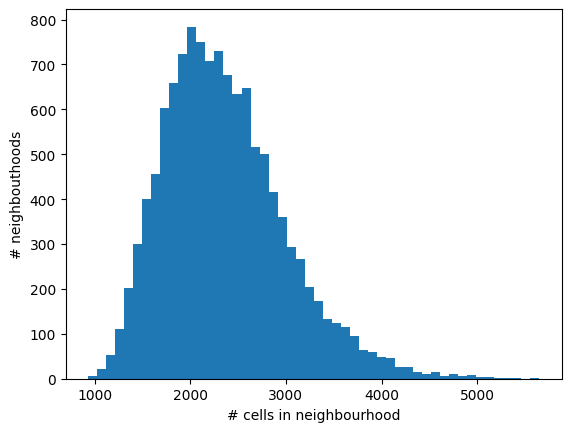

In [20]:
nhood_size = adata.obsm['nhoods'].toarray().sum(0)
plt.hist(nhood_size, bins=50);
plt.xlabel('# cells in neighbourhood');
plt.ylabel('# neighbouthoods');

### Count cells in neighbourhoods

In [21]:
adata.obs['donor_id'] = adata.obs['donor_id'].astype('str') ## Needed for subsetting
milo.count_nhoods(adata, sample_col = 'donor_id')

In [22]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'


adata.write_h5ad(h5ad_path+'Myeloid_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

#adata = sc.read_h5ad(h5ad_path+'Myeloid_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [23]:
sample_cols = ['dataset_id', 'donor_id', 'tissue', 'disease', 'cell_source', 'Cell_type_scANVI']
sample_df = adata.obs[sample_cols].groupby(sample_cols).size().reset_index()
sample_df.columns = sample_cols + ['n_cells']
sample_df = sample_df[sample_df['n_cells'] > 0].copy()

In [24]:
adata

AnnData object with n_obs × n_vars = 246528 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'to

In [25]:
import gc
gc.collect()

34

## Run differential abundance test

### 1. Use paired case-controls

For each test restrict to case-control in the same disease

In [26]:
def plot_milo_diagnostics(milo_res):
    '''Function to plot diagnostic plots 
    as in extended vignette https://github.com/Teichlab/scripts/blob/main/conditions/extended_milopy_example.ipynb
    '''
    nhood_adata = adata.uns['nhood_adata'].copy()
    alpha = 0.1 ## significance threshold

    with matplotlib.rc_context({'figure.figsize':[8,8]}):

        ## Check P-value histogram
        plt.subplot(2,2,1);
        plt.hist(milo_res['PValue'], bins=20);
        plt.xlabel('Uncorrected P-value');

        ## Visualize extent of multiple-testing correction
        plt.subplot(2,2,2);
        plt.scatter(milo_res['PValue'], milo_res['SpatialFDR'], s=3);
        plt.xlabel('Uncorrected P-value');
        plt.ylabel('SpatialFDR');

        ## Visualize volcano plot
        plt.subplot(2,2,3);
        plt.scatter(milo_res['logFC'], -np.log10(milo_res['SpatialFDR']), s=3);
        plt.axhline(y=-np.log10(alpha), color='red', linewidth=1, label=f'{int(alpha*100)} % SpatialFDR');
        plt.legend();
        plt.xlabel('log-Fold Change');
        plt.ylabel('- log10(SpatialFDR)');
        plt.tight_layout()

        ## Visualize MA plot
        df = milo_res
        emp_null = df[df['SpatialFDR'] >= alpha]['logFC'].mean()
        df['Sig'] = df['SpatialFDR'] < alpha

        plt.subplot(2,2,4);
        sns.scatterplot(data=df, x="logCPM", y="logFC", hue='Sig')
        plt.axhline(y=0, color='grey', linewidth=1)
        plt.axhline(y=emp_null, color='purple', linewidth=1);
        plt.legend(title=f'< {int(alpha*100)} % SpatialFDR')
        plt.xlabel('Mean log-counts');
        plt.ylabel('log-Fold Change');
        plt.show()
        
def run_DA_autoimmune(adata, sample_df, DA_test_dict):
    '''Wrapper function to run differential abundance testing on autoimmune dataset
    '''
    
    adata.obs['disease_test'] = np.where(adata.obs['disease'].isin(DA_test_dict['disease']), 1, 0)
    
    test_samples = sample_df['donor_id'][sample_df['dataset_id'] == DA_test_dict['dataset_id']].astype('str').values
    
    milo.DA_nhoods(adata, 
                   design="~ donor_id + disease_test",
                   subset_samples=test_samples.tolist()
                  )
    milo_results = adata.uns["nhood_adata"].obs.copy() ## Store results for each disease
    plot_milo_diagnostics(milo_results.dropna())
    return(milo_results)


In [27]:
np.unique(adata.obs.dataset_id)

array(['GSE134809_Martin_et_al_2019', 'GSE157278_Hong_2020',
       'GSE163314_Lefferts_2021', 'Martin_JIA_2019', 'Perez_2022',
       'Qian_Yue_Zhang_2022'], dtype=object)

In [28]:
adata.obs[["dataset_id", "disease"]].value_counts().sort_index()

dataset_id                   disease                     
GSE134809_Martin_et_al_2019  Crohn's Disease                   2868
GSE157278_Hong_2020          Healthy                           2732
                             Sjögren’s syndrome                3763
GSE163314_Lefferts_2021      CD + Spondyloarthritis             423
                             Crohn's Disease                   3057
                             Healthy                           1544
                             Spondyloarhtritis                 3047
Martin_JIA_2019              Oligoarticular JIA                3215
Perez_2022                   Healthy                         101492
                             Systemic lupus erythematosus    110925
Qian_Yue_Zhang_2022          Hashimoto’s thyroiditis          13462
dtype: int64

In [36]:
DA_test_dict = {
    ## Define parameters for each test
    'martin_cd':{'dataset_id':'GSE134809_Martin_et_al_2019', 'disease':["Crohn's Disease"]},#
    'martin_uninfl_CD':{'dataset_id':'GSE134809_Martin_et_al_2019', 'disease':["Uninflamed CD"]},
    'stefeno_RA':{'dataset_id':'E-MTAB-8322_Stefeno_2020', 'disease':['Rheumatoid Arthritis']},
    'stefeno_undef_RA':{'dataset_id':'E-MTAB-8322_Stefeno_2020', 'disease':['Undifferentiated Arthritis']},
    'lefferts_spondy':{'dataset_id':'GSE163314_Lefferts_2021', 'disease':['Spondyloarthritis']},#
    'lefferts_cd_spon':{'dataset_id':'GSE163314_Lefferts_2021', 'disease':['CD + Spondyloarthritis']},#
    'lefferts_cd':{'dataset_id':'GSE163314_Lefferts_2021', 'disease':["Crohn's Disease"]},#
    #'huang_paed_IBD':{'dataset_id':'GSE121380_Huang_2019', 'disease':['Paediatric IBD']},
    'Elmentaite_2020':{'dataset_id':'Elmentaite_2020', 'disease':["Crohn's Disease"]},
    #'amp_RA':{'dataset_id':'AMP_phase1_RA', 'disease':['Rheumatoid Arthritis']},
    #'amp_OA':{'dataset_id':'AMP_phase1_RA', 'disease':['Osteoarthritis']},
    #'abji_psoriasticA':{'dataset_id':'GSE161500_Abji_2020', 'disease':['Psoriatic arthritis']},
    #'martin_JIA':{'dataset_id':'Martin_JIA_2019', 'disease':['Oligoarticular JIA']},
    #'qian_hashi':{'dataset_id':'Qian_Yue_Zhang_2022', 'disease':['Hashimoto’s thyroiditis']}
}

In [29]:
DA_test_res = {}

In [38]:
#for k in DA_test_dict.keys():
  #  print(k)
 #   DA_test_res[k] = run_DA_autoimmune(adata, sample_df, DA_test_dict=DA_test_dict[k])

Comments:

- Except for the Hong dataset, in all other cases there seems to be too little replicates per condition to detect significant differential abundance in this dataset

### 2. Use all healthy as controls

Tricky because we can't control for the batch effect between datasets (for some conditions we don't have data from all the datasets)

In [30]:
diseases_short

{'CD + Spondyloarthritis': 'CD_and_spondoarthritis',
 'Spondyloarhtritis': 'spondoarthritis',
 "Crohn's Disease": 'CD',
 'Healthy': 'Healthy',
 'Hashimoto’s thyroiditis': 'hashimoto',
 'Oligoarticular JIA': 'Oligo_JIA',
 'Systemic lupus erythematosus': 'SLE',
 'Sjögren’s syndrome': 'sjo_syndr'}

In [31]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortCD-disease_shortHealthy'
              )
DA_test_res['all_CD'] = adata.uns['nhood_adata'].obs.copy()

In [32]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortCD_and_spondoarthritis-disease_shortHealthy'
              )
DA_test_res['all_CD_and_spondoarthritis'] = adata.uns['nhood_adata'].obs.copy()

In [33]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortspondoarthritis-disease_shortHealthy'
              )
DA_test_res['all_spondoarthritis'] = adata.uns['nhood_adata'].obs.copy()

In [34]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortsjo_syndr-disease_shortHealthy'
              )
DA_test_res['all_sjo_syndr'] = adata.uns['nhood_adata'].obs.copy()

milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortSLE-disease_shortHealthy'
              )
DA_test_res['all_SLE'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shorthashimoto-disease_shortHealthy'
              )
DA_test_res['all_hashimoto'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortOligo_JIA-disease_shortHealthy'
              )
DA_test_res['all_Oligo_JIA'] = adata.uns['nhood_adata'].obs.copy()

all_CD


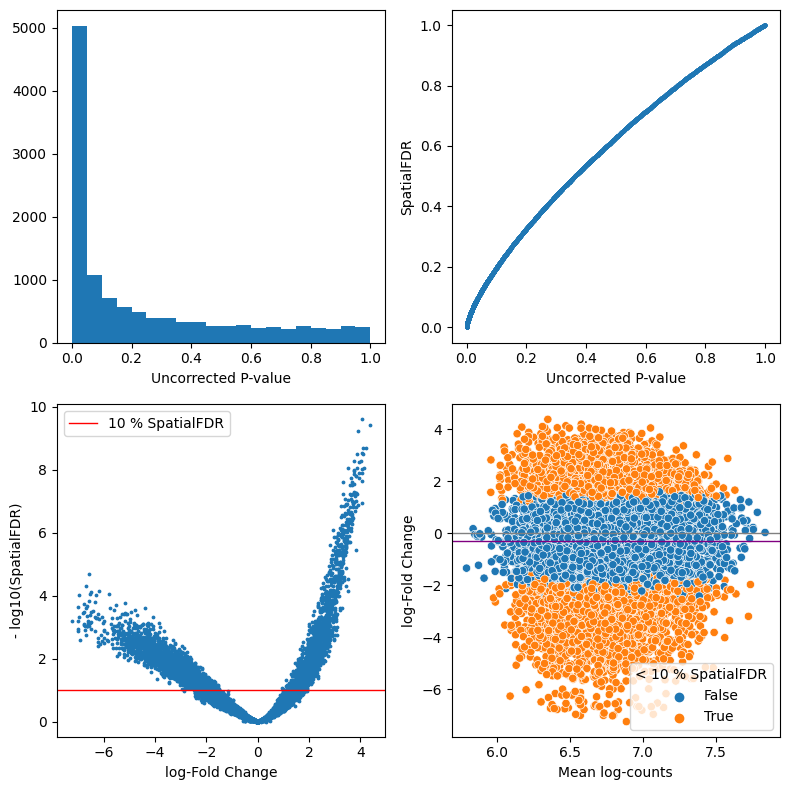

all_CD_and_spondoarthritis


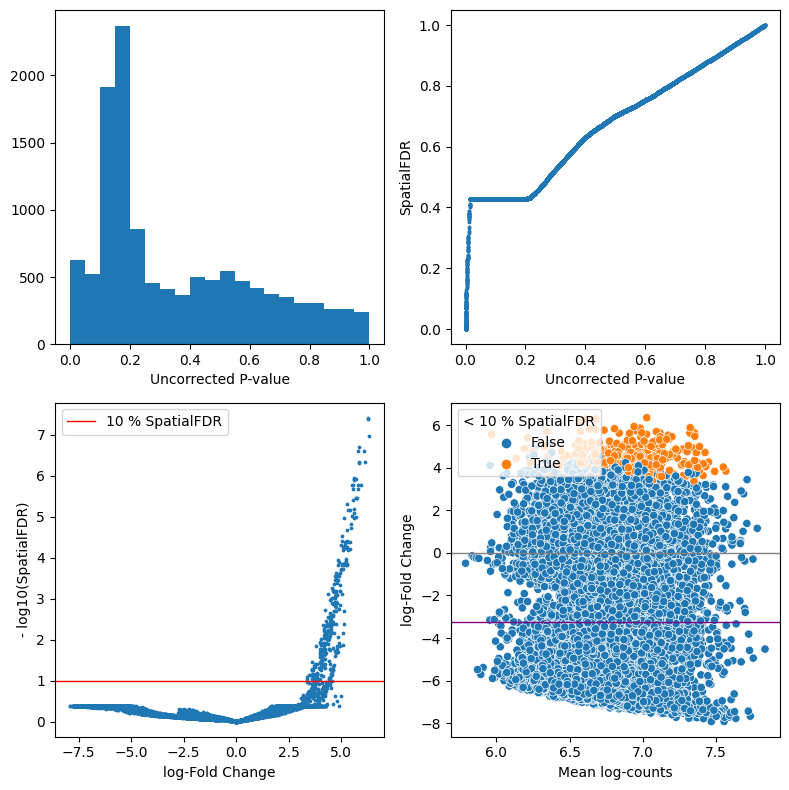

all_spondoarthritis


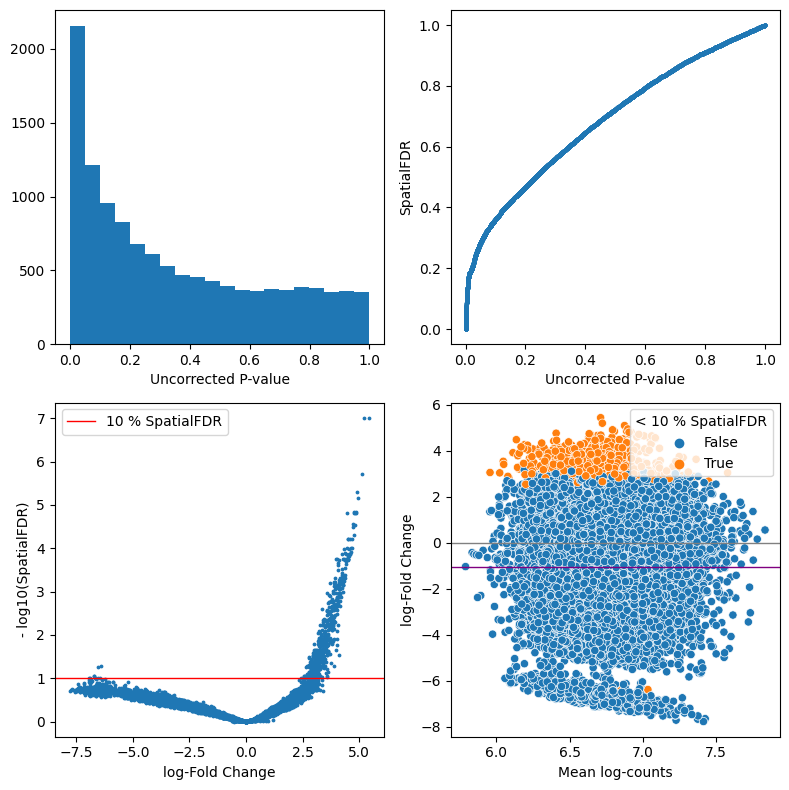

all_sjo_syndr


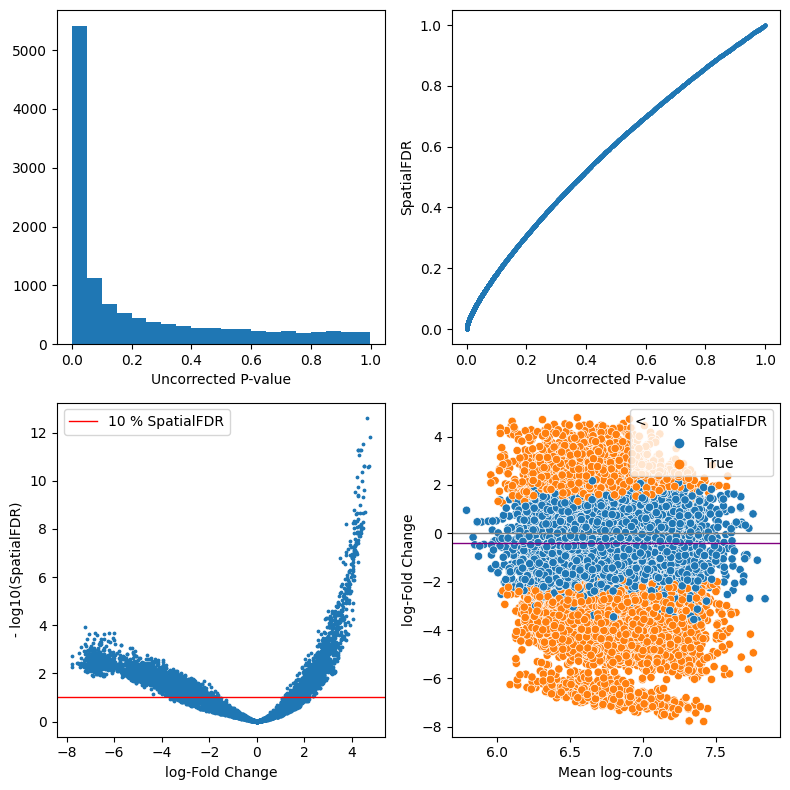

all_SLE


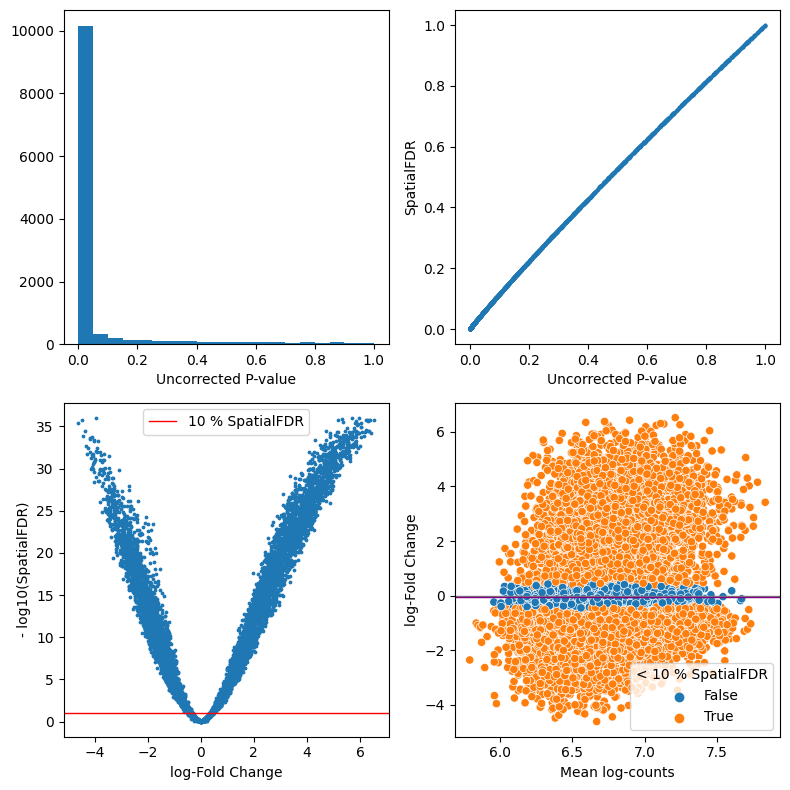

all_hashimoto


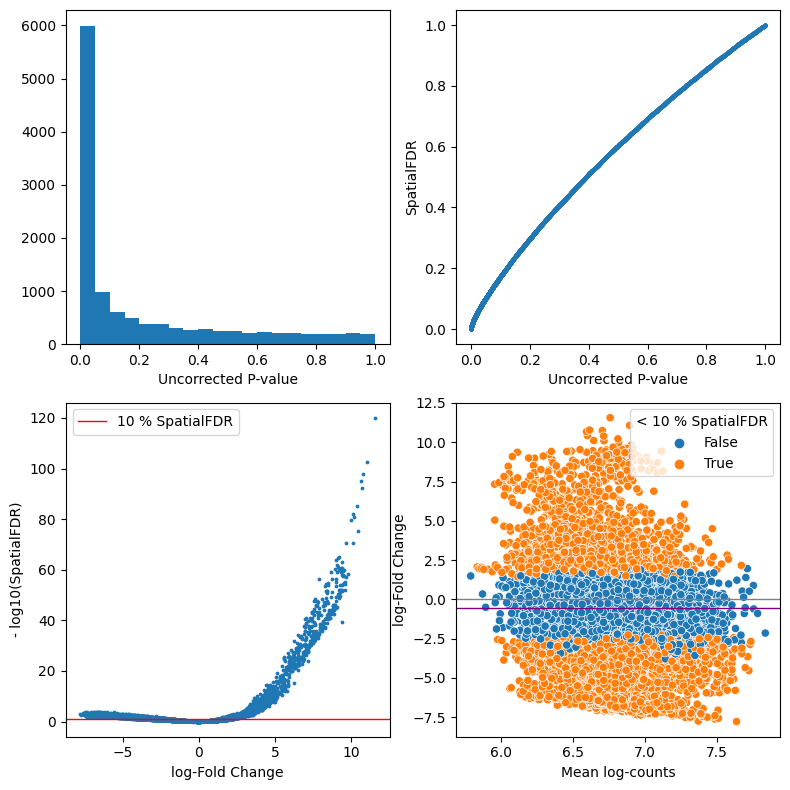

all_Oligo_JIA


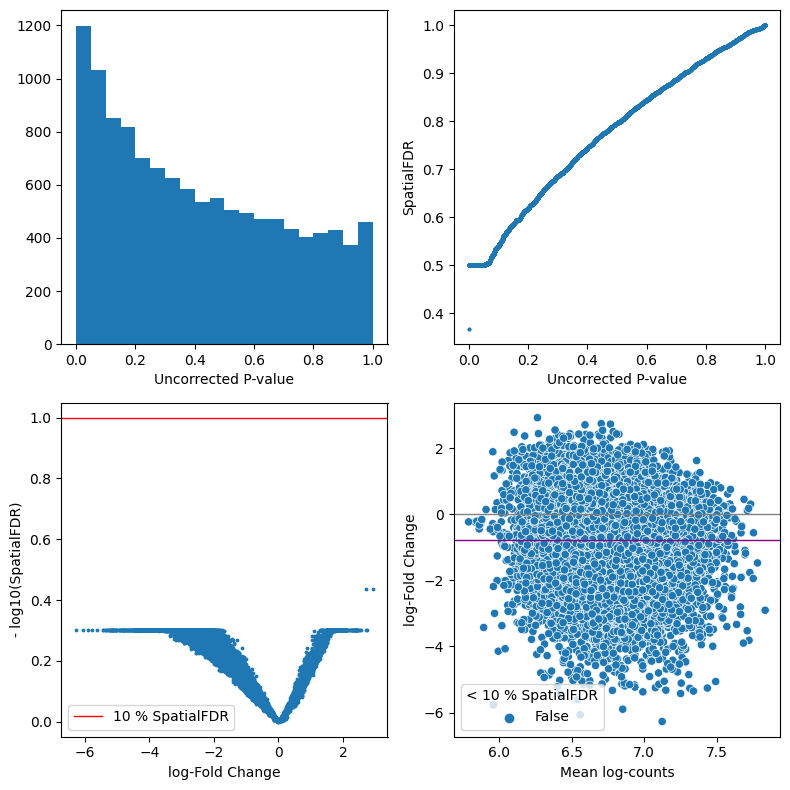

In [35]:
for k in DA_test_res.keys():
    if k.startswith("all_"):
        print(k)
        plot_milo_diagnostics(DA_test_res[k])

Comments:

- In `all_asthma` we see skewed distribution of depleted neighbourhoods (i.e. enriched in Healthy), likely because of the imbalance in number of Healhty and disease donors
- All the others look reasonable in terms of diagnostic statistics, although we might have false positives from batch effects 

## Visualize results by cell type

We select the DA tests where the diagnostic plots look reasonable.

In [37]:
diseases_short

{'CD + Spondyloarthritis': 'CD_and_spondoarthritis',
 'Spondyloarhtritis': 'spondoarthritis',
 "Crohn's Disease": 'CD',
 'Healthy': 'Healthy',
 'Hashimoto’s thyroiditis': 'hashimoto',
 'Oligoarticular JIA': 'Oligo_JIA',
 'Systemic lupus erythematosus': 'SLE',
 'Sjögren’s syndrome': 'sjo_syndr'}

In [38]:
keep_tests = ["all_"+val for val in diseases_short.values() if val not in ['CD_and_spondoarthritis', 'Oligo_JIA', "spondoarthritis", "Healthy"]]


In [39]:
keep_tests

['all_CD', 'all_hashimoto', 'all_SLE', 'all_sjo_syndr']

Visualize DA logFC on gene expression UMAP

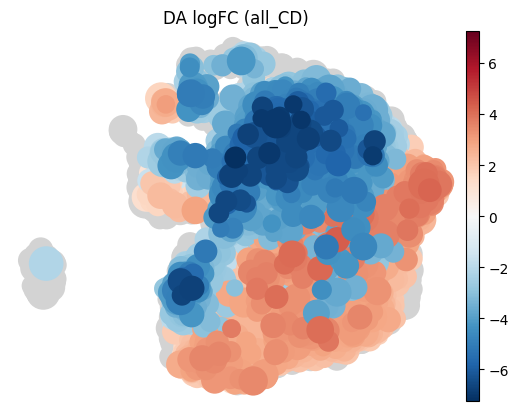

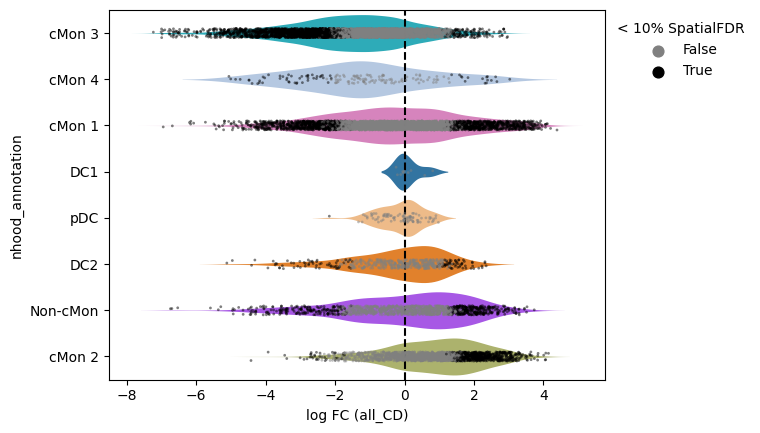

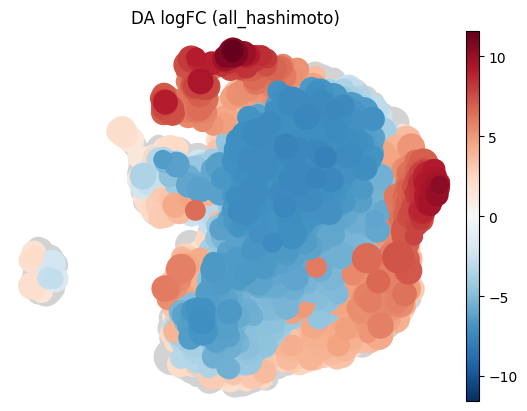

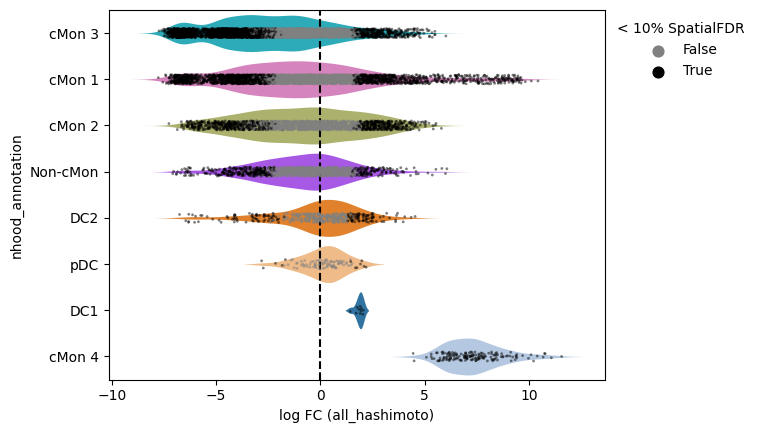

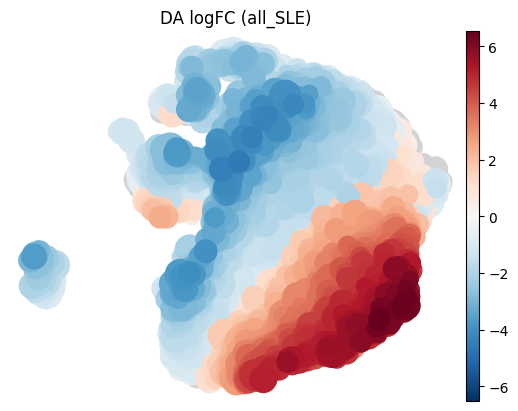

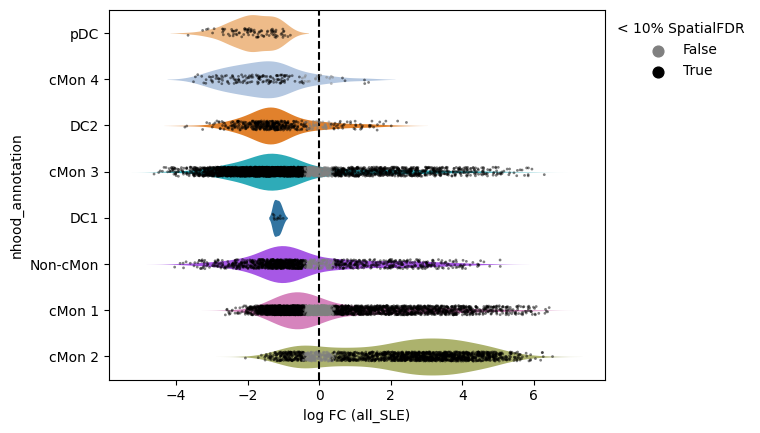

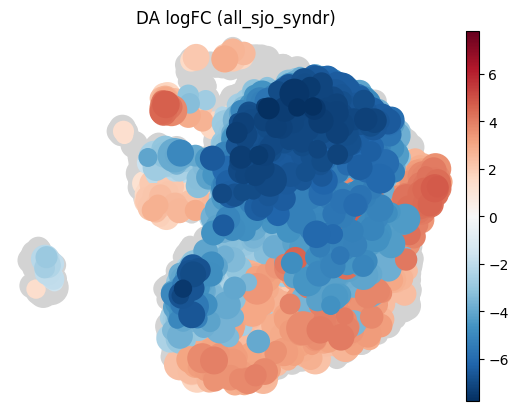

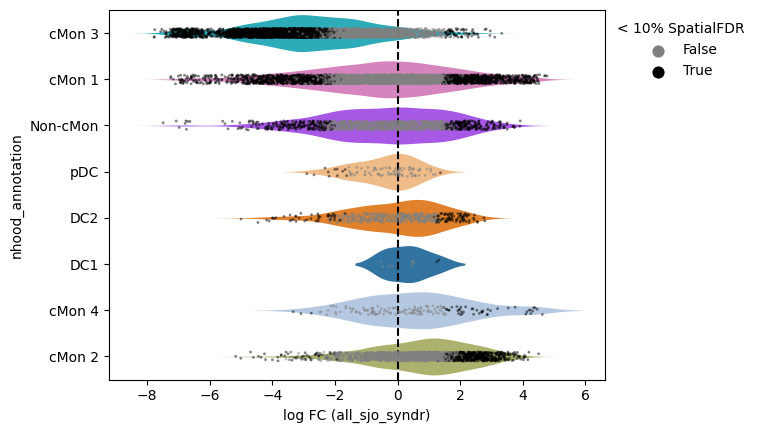

In [40]:
for k in keep_tests:
    #if k == 'all_CD_and_spondoarthritis':
     #   continue
    
    adata.uns['nhood_adata'].obs = DA_test_res[k].copy()

    ## Plot neighbourhoods on embedding
    milopy.utils.build_nhood_graph(adata)
    milopy.plot.plot_nhood_graph(adata, alpha=0.1, min_size=0.5, title=f'DA logFC ({k})');

    ## Plot by cell type
    milopy.utils.annotate_nhoods(adata, anno_col='Cell_type_scANVI')
    milopy.plot.plot_DA_beeswarm(adata, alpha=0.1);
    plt.xlabel(f'log FC ({k})');
    plt.show()

In [41]:
res_cols = ['logFC', 'SpatialFDR', 'Sig', 'index_cell']

In [42]:
disease_df = []
nhood_annotation = np.array(adata.uns["nhood_adata"].obs['nhood_annotation'])
cell_ind = np.array(adata.uns["nhood_adata"].obs['index_cell'])
for disease in keep_tests:
    
    tab = DA_test_res[disease][res_cols]
    #check if index_cell columns are in the same order
    if any(np.array(adata.uns["nhood_adata"].obs['index_cell']) != tab['index_cell']):
        raise Exception("index_cell don't match...")
    tab["disease"] = np.repeat(disease, tab.shape[0])
    tab["nhood_annotation"] = nhood_annotation
    disease_df.append(tab)

In [43]:
adata.uns["nhood_adata"].obs["Sig"].value_counts()

False    6804
True     5217
Name: Sig, dtype: int64

In [44]:
#Check number of neighbourhoods
disease_df[0]['nhood_annotation'].value_counts()

cMon 3      4429
cMon 1      3853
cMon 2      1774
Non-cMon    1258
DC2          452
cMon 4       155
pDC           90
DC1           10
Name: nhood_annotation, dtype: int64

In [45]:
compare_disease_df = pd.concat(disease_df)

In [46]:
compare_disease_df.disease.value_counts()

all_CD           12021
all_hashimoto    12021
all_SLE          12021
all_sjo_syndr    12021
Name: disease, dtype: int64

## Save


In [51]:
compare_disease_df.to_csv(h5ad_path+"Myeloid_From_PBMC_label_transfer_Milo_3K.csv")

In [16]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'

compare_disease_df = pd.read_csv(h5ad_path+"Myeloid_From_PBMC_label_transfer_Milo_3K.csv",
                                index_col=0)

In [25]:
h5ad_path+"Myeloid_From_PBMC_label_transfer_Milo_3K.csv"

'/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/Myeloid_From_PBMC_label_transfer_Milo_3K.csv'

In [94]:
adata.obs[['Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance']]

,Cell_type_scANVI,disease_short,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance
AAAGTAGTCCGAATGT-1_0_0_0_0-0,cMon 2,hashimoto,0,0,0.0
AAAGTAGTCCGCAAGC-1_0_0_0_0-0,Non-cMon,hashimoto,0,0,0.0
AAATGCCTCTGAGGGA-1_0_0_0_0-0,cMon 3,hashimoto,1,0,0.0
AACACGTGTTGTACAC-1_0_0_0_0-0,cMon 1,hashimoto,0,0,0.0
AACACGTTCCACGTGG-1_0_0_0_0-0,cMon 1,hashimoto,0,0,0.0
...,...,...,...,...,...
TTTGCGCAGACAGAGA-1-1-1-1-1-1-1-1-1_1_0-1,cMon 1,Healthy,0,0,0.0
TTTGGTTAGCGTCTAT-1-1-1-1-1-1-1-1-1_1_0-1,cMon 3,Healthy,0,0,0.0
TTTGGTTCATCTGGTA-1-1-1-1-1-1-1-1-1_1_0-1,DC2,Healthy,0,0,0.0
TTTGTCACATTATCTC-1-1-1-1-1-1-1-1-1_1_0-1,DC2,Healthy,0,0,0.0


## Milo DEG

In [8]:
adata

AnnData object with n_obs × n_vars = 246724 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'to

In [56]:
def nhoo_test_data(adata, dir_fc, cell_type, nhoo_fc, n_disease, dis_pref="all_", disease_label = "disease_short"):
    '''
    Prepare adata for DE testing in neighbourhoods. Cells in neighbourhoods with significant enrichment or depletion in at least two 
    diseases are selected and subsequently used to subset the anndata object.
    
    Params:
    -------
    - nhoo_fc: long format dataframe containing milo testing results of all diseases
    - disease_set: list of two or more diseases in which neighbourhoods are simultaneously depleted or enriched 
    - cell_type: str or list of cell types to test in
    - dir_fc str indicating the direction of the fold abundance (ie depleted or enriched)
    - cell_type_label label of column containing manually annotated
    
    
    
    '''
    
    #selected_nhoo_df = nhoo_fc[(nhoo_fc.disease.isin(disease_set)) & (nhoo_fc.nhood_annotation.isin(cell_type))]
    selected_nhoo_df = nhoo_fc[nhoo_fc.nhood_annotation.isin(cell_type)]

    selected_nhoo_df.reset_index(drop=True, inplace=True)
    #check depletion
    cond1 = ((selected_nhoo_df.logFC < 0) & (selected_nhoo_df.Sig))
    #check enrichment
    cond2 = ((selected_nhoo_df.logFC > 0) & (selected_nhoo_df.Sig))
    
    selected_nhoo_df["dir_FC"] = np.where(cond1, "Depleted", 
        np.where(cond2, "Enriched", "Non_sig"))

    #check the indicated direction of FC and save to test_nhoo column
    selected_nhoo_df["test_nhoo"] = np.where(selected_nhoo_df.dir_FC==dir_fc.capitalize(), True, False)
    
    print("")
    print(f"shape of selected_nhoo_df: {selected_nhoo_df.shape}")
    #transfrom in wide data frame and conserve only nhoo names(index_cell)
    selected_nhoo_df = pd.pivot(selected_nhoo_df, index=['index_cell'], columns="disease", values="test_nhoo")

    #Identify cells that match the condictions in all diseases
    selected_nhoo_df["selected_nhoo"] = selected_nhoo_df.values.sum(axis=1)
    
    #selected_nhoo_df.selected_nhoo.replace([0,1], ["divergent", "shared"], inplace=True)
    selected_nhoo_df["selected_nhoo"] = np.where(selected_nhoo_df.selected_nhoo >= n_disease,
                                                "shared", "rest")
    
    selected_nhoo_df["selected_nhoo"] = selected_nhoo_df.selected_nhoo.astype('category')
    
    print("selected_nhoo_df")
    print(selected_nhoo_df.shape)
    #subset adata to maintain only cells of interest
    adata0 = adata[adata.obs.Cell_type_scANVI.isin(cell_type)].copy()
    print("adata0")
    print(adata0.shape)
    gc.collect()
    #Index of selected cells
    ind_cel = np.array(np.where(adata.obs.Cell_type_scANVI.isin(cell_type))).flatten()
    
    #Select cells that appear in at least one nhoo
        #Shared
    shared_nhoo = selected_nhoo_df.selected_nhoo[selected_nhoo_df.selected_nhoo == "shared"].index #shared index
    
    ind_shared = np.where(adata.uns["nhood_adata"].obs.index_cell.isin(shared_nhoo))
    
    ind_shared = np.array(ind_shared).flatten()
    
    cells_in_nhoods_sh = adata.obsm["nhoods"][:,ind_shared].toarray().sum(1) > 0

    cells_in_nhoods_sh_2 = adata0.obs_names[cells_in_nhoods_sh[ind_cel]]
    
    adata0.obs["nhoo_test_condition"] = np.where(adata0.obs_names.isin(cells_in_nhoods_sh_2), "shared", "rest")
                                            
    print(adata0.obs["nhoo_test_condition"].value_counts())

    return adata0

In [54]:
from IPython.display import display

In [10]:
#test_adata = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=cell_type, 
 #              dis_pref="all_", disease_label = "disease_short", nhoo_fc=compare_disease_df,
  #                         compare_with=compare_with)

We run DEG analysis using MAST in R as recommended by https://www.sc-best-practices.org/conditions/differential_gene_expression.html#notes-on-edger

In [55]:
def prep_anndata(adata_):
    # Count will be used
    adata_.X = adata_.layers["counts"].copy()
    def fix_dtypes(adata_):
        df = pd.DataFrame(adata_.X.A, index=adata_.obs_names, columns=adata_.var_names)
        df = df.join(adata_.obs)
        return sc.AnnData(df[adata_.var_names], obs=df.drop(columns=adata_.var_names))

    adata_ = fix_dtypes(adata_)
    sc.pp.filter_genes(adata_, min_cells=10)
    return adata_

## Save prepared data


In [57]:
compare_disease_df.nhood_annotation.unique()

array(['cMon 1', 'cMon 4', 'DC2', 'cMon 2', 'cMon 3', 'Non-cMon', 'DC1',
       'pDC'], dtype=object)

#### Depleted


In [58]:
#depletion
nhoo_fc=compare_disease_df
n_disease_dict = {
    'cMon 1':4,
    #'cMon 2':5,
    'cMon 3':4,
    #'cMon 4':6,
    'Non-cMon':3,
    #'DC1':5,
    #'pDC':
}

cell_set = [k for k in n_disease_dict.keys()]

dis_pref="all_"
disease_label = "disease_short"
cell_type_label = "Cell_type_scANVI"
dir_fc = "depleted"
#compare_with = False
depl_adatas = []

for cel in cell_set:
    print(f"\n processing {cel}...\n")
    
    test_adata_ = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=[cel], dis_pref="all_", 
                                disease_label = "disease_short", nhoo_fc=compare_disease_df, 
                                 n_disease=n_disease_dict[cel])

    if(len(test_adata_.obs.nhoo_test_condition.unique()) == 1):
        print(f"Check Category of removed data: {test_adata_.obs.nhoo_test_condition.unique()}")
        continue
    
    print("n_disease")
    print(test_adata_.obs.disease_short.value_counts())
    
    gc.collect()
    depl_adatas.append(test_adata_)
    
    del test_adata_

depleted_adata = depl_adatas[0].concatenate(depl_adatas[1:])


 processing cMon 1...


shape of selected_nhoo_df: (15412, 8)
selected_nhoo_df
(3853, 5)
adata0
(72804, 20301)
shared    40721
rest      32083
Name: nhoo_test_condition, dtype: int64
n_disease
SLE                       34646
Healthy                   27757
hashimoto                  5008
CD                         1986
sjo_syndr                  1463
spondoarthritis             998
Oligo_JIA                   892
CD_and_spondoarthritis       54
Name: disease_short, dtype: int64

 processing cMon 3...


shape of selected_nhoo_df: (17716, 8)
selected_nhoo_df
(4429, 5)
adata0
(83965, 20301)
shared    65802
rest      18163
Name: nhoo_test_condition, dtype: int64
n_disease
Healthy                   47564
SLE                       32805
Oligo_JIA                  1256
CD                          918
hashimoto                   602
sjo_syndr                   582
spondoarthritis             228
CD_and_spondoarthritis       10
Name: disease_short, dtype: int64

 processing Non-cMon...


shape

In [59]:
depleted_adata

AnnData object with n_obs × n_vars = 183300 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'nhoo_test_condition'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by

In [60]:
#depleted_adata = prep_anndata(adata_=depleted_adata)

In [61]:
depleted_adata

AnnData object with n_obs × n_vars = 183300 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'nhoo_test_condition'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by

In [62]:
h5ad_path+"depleted_nhoo/"

'/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/depleted_nhoo/'

In [40]:
!rm -r '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/depleted_nhoo/'
!mkdir '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/depleted_nhoo/'

In [63]:
gc.collect()

357

In [64]:
depleted_adata.write_h5ad(h5ad_path+"depleted_nhoo/PBMC_Myeloid_depleted_Milo_adata.h5ad")

In [65]:
del depleted_adata

In [66]:
del depl_adatas

#### Enriched

In [67]:
#Enrichment
gc.collect()
nhoo_fc=compare_disease_df
n_disease_dict = {
    'cMon 1':4,
    'cMon 2':3,
    'Non-cMon':3
}

cell_set = [k for k in n_disease_dict.keys()]

dis_pref="all_"
disease_label = "disease_short"
cell_type_label = "Cell_type_scANVI"
dir_fc = "enriched"
#compare_with = True
enriched_adatas = []

for cel in cell_set:

    cell_type = [cel]
    print(f"\n processing {cel}...\n")

    test_adata = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=cell_type, 
                                dis_pref="all_", disease_label = "disease_short", 
                                nhoo_fc=compare_disease_df, n_disease=n_disease_dict[cel])

    if(len(test_adata.obs.nhoo_test_condition.unique()) == 1):
        print(f"Check Category of removed data: {test_adata.obs.nhoo_test_condition.unique()}")
        continue
    
    print("n_disease")
    print(test_adata.obs.disease_short.value_counts())
    
    enriched_adatas.append(test_adata)

enriched_adata = enriched_adatas[0].concatenate(enriched_adatas[1:])


 processing cMon 1...


shape of selected_nhoo_df: (15412, 8)
selected_nhoo_df
(3853, 5)
adata0
(72804, 20301)
rest      40874
shared    31930
Name: nhoo_test_condition, dtype: int64
n_disease
SLE                       34646
Healthy                   27757
hashimoto                  5008
CD                         1986
sjo_syndr                  1463
spondoarthritis             998
Oligo_JIA                   892
CD_and_spondoarthritis       54
Name: disease_short, dtype: int64

 processing cMon 2...


shape of selected_nhoo_df: (7096, 8)
selected_nhoo_df
(1774, 5)
adata0
(37461, 20301)
shared    34037
rest       3424
Name: nhoo_test_condition, dtype: int64
n_disease
SLE                       27335
Healthy                    6801
CD                         1165
spondoarthritis             773
sjo_syndr                   594
hashimoto                   546
Oligo_JIA                   206
CD_and_spondoarthritis       41
Name: disease_short, dtype: int64

 processing Non-cMon...


shape 

In [68]:
del adata
gc.collect()

289

In [47]:
!rm -r '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/enriched_nhoo/'
!mkdir '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/enriched_nhoo/'

In [48]:
#enriched_adata = prep_anndata(adata_=enriched_adata)

In [69]:
enriched_adata.write_h5ad(h5ad_path+"enriched_nhoo/PBMC_Myeloid_enriched_Milo_adata.h5ad")

In [70]:
del enriched_adata

In [71]:
del test_adata
del enriched_adatas
gc.collect()

3075

In [79]:
#h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/'

#adata = sc.read_h5ad(h5ad_path+'Myeloid_From_Tissue_label_transfert_With_MiloData_3K.h5ad')

## Milo horizontal plot

In [47]:
compare_disease_df

,logFC,SpatialFDR,Sig,index_cell,disease,nhood_annotation
0,3.883760,6.100833e-08,True,AAACCTGGTCCATCCT-1_0_0_0_0-0,all_CD,cMon 1
1,3.785215,6.789328e-08,True,AAAGATGAGCGTTGCC-1_0_0_0_0-0,all_CD,cMon 1
2,1.826367,2.374764e-02,True,AAAGCAAAGAATCTCC-1_0_0_0_0-0,all_CD,cMon 4
3,3.590004,8.406534e-07,True,AACCGCGAGCAGCGTA-1_0_0_0_0-0,all_CD,cMon 1
4,3.397812,1.950358e-06,True,AACCGCGAGCTAGGCA-1_0_0_0_0-0,all_CD,cMon 1
...,...,...,...,...,...,...
12016,2.756458,8.123935e-04,True,GAATAAGTCCGAACGC-0-1_1_0-1,all_sjo_syndr,Non-cMon
12017,0.745020,4.602958e-01,False,CACCACTTCACAGGCC-0-1-1-1_1_0-1,all_sjo_syndr,cMon 2
12018,4.132019,5.792451e-09,True,TAAGCGTTCGAACGGA-0-1-1-1_1_0-1,all_sjo_syndr,cMon 1
12019,4.132115,4.555398e-08,True,TGTATTCCAGTTAACC-0-1-1-1-1_1_0-1,all_sjo_syndr,cMon 1


In [48]:
%%R
#colors
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/colors.R")

In [49]:
compare_disease_df.disease = compare_disease_df.disease.astype("category")

In [50]:
%%R -i compare_disease_df -w 40 -h 15 --units in -r 600
# Source plotting code
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/plot_AIID.R")
#head(compare_disease_df)

compare_disease_df$Sig = ifelse(compare_disease_df$Sig == 1, TRUE, FALSE)
#print(table(compare_disease_df$Sig))
#### Prepare data

nhoo_prep = prep_nhoo(nhood_res=compare_disease_df, condition = "disease", Sig = "Sig", thres = 0.1,
                     dis_pref = "all_", index_cell = "index_cell", 
                     nhood_annotation="nhood_annotation", n_shared=0,
                     SpatialFDR = "SpatialFDR", logFC = "logFC")
  

milo_hori_plot = milo_plot_list(nhoo_prep = nhoo_prep, rel_widths = c(1, 0.25),
                                rel_heights = c(3, 2), col.pal=vega_20)

milo_hori_plot

In [14]:
%%R
rm(compare_disease_df)

## DEG MAST

In [7]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'


test_adata_enriched = sc.read_h5ad(h5ad_path+"enriched_nhoo/PBMC_Myeloid_enriched_Milo_adata.h5ad")

test_adata_depleted = sc.read_h5ad(h5ad_path+"depleted_nhoo/PBMC_Myeloid_depleted_Milo_adata.h5ad")

In [8]:
test_adata_enriched = test_adata_enriched[test_adata_enriched.obs.nhoo_test_condition=="shared"].copy()

test_adata_depleted = test_adata_depleted[test_adata_depleted.obs.nhoo_test_condition=="shared"].copy()

In [9]:
test_adata_enriched.obs.nhoo_test_condition.replace("shared", "enriched", inplace=True)
test_adata_depleted.obs.nhoo_test_condition.replace("shared", "depleted", inplace=True)

In [10]:
M1 = test_adata_depleted[test_adata_depleted.obs.Cell_type_scANVI=="cMon 1"].copy()
M2 = test_adata_enriched[test_adata_enriched.obs.Cell_type_scANVI=="cMon 2"].copy()


In [11]:
adata_M1_vs_M2 = M1.concatenate(M2)

In [12]:
adata_M1_vs_M2.obs["Cell_type_scANVI"] = [
    ct.replace(" ", "_") for ct in adata_M1_vs_M2.obs["Cell_type_scANVI"]
]
adata_M1_vs_M2.obs["Cell_type_scANVI"] = [
    ct.replace("+", "_plus") for ct in adata_M1_vs_M2.obs["Cell_type_scANVI"]
]

adata_M1_vs_M2.obs["Cell_type_scANVI"] = [
    ct.replace("-", "_") for ct in adata_M1_vs_M2.obs["Cell_type_scANVI"]
]

adata_M1_vs_M2.obs["donor_id"] = [
    ct.replace("-", "_") for ct in adata_M1_vs_M2.obs["donor_id"]
]

adata_M1_vs_M2.obs["donor_id"] = [
    ct.replace(" ", "_") for ct in adata_M1_vs_M2.obs["donor_id"]
]


In [13]:
adata_M1_vs_M2.obs[["Cell_type_scANVI", "nhoo_test_condition"]].value_counts()

Cell_type_scANVI  nhoo_test_condition
cMon_1            depleted               40468
cMon_2            enriched               29422
dtype: int64

In [14]:
adata_M1_vs_M2.obs = adata_M1_vs_M2.obs[['tissue', 'disease_short', 'donor_id', 'dataset_id',
                                        'development_stage', 'disease_state', 
                                        'Cell_type_scANVI', 'nhoo_test_condition']]

In [15]:
del M1
del M2
gc.collect()

498

In [16]:
%%R
find_de_MAST_RE_2 <- function(adata_, ref, test_grp, cel){
    # create a MAST object
    sca <- SceToSingleCellAssay(adata_, class = "SingleCellAssay")
    print("Dimensions before subsetting:")
    print(dim(sca))
    print("")
    # keep genes that are expressed in more than 10% of all cells
    sca <- sca[freq(sca)>0.1,]
    print("Dimensions after subsetting:")
    print(dim(sca))
    print("")
    # add a column to the data which contains scaled number of genes that are expressed in each cell
    cdr2 <- colSums(assay(sca)>0)
    colData(sca)$ngeneson <- scale(cdr2)
    # store the columns that we are interested in as factors
    label <- factor(colData(sca)$nhoo_test_condition)
    # set the reference level
    label <- relevel(label,ref)
    colData(sca)$label <- label
    celltype <- factor(colData(sca)$Cell_type_scANVI)
    colData(sca)$celltype <- celltype
    # same for donors (which we need to model random effects)
    replicate <- factor(colData(sca)$donor_id)
    colData(sca)$replicate <- replicate
    ## same for disease
    disease_short <- factor(colData(sca)$disease_short)
    colData(sca)$disease_short <- disease_short
    # create a group per condition-celltype combination
    
    colData(sca)$group <- paste0(colData(adata_)$nhoo_test_condition, ".", colData(adata_)$Cell_type_scANVI)
    colData(sca)$group <- factor(colData(sca)$group)
    print("group")
    print(levels(colData(sca)$group))
    # define and fit the model
    zlmCond <- zlm(formula = ~ngeneson + group + (1 | replicate) + (1 | disease_short), 
                   sca=sca, 
                   method='glmer', 
                   ebayes=F, 
                   strictConvergence=F,
                   fitArgsD=list(nAGQ = 0)) # to speed up calculations
    
    # perform likelihood-ratio test for the condition that we are interested in    
    summaryCond <- summary(zlmCond, doLRT=stringr::str_glue('group{test_grp}.{cel}'))
    # get the table with log-fold changes and p-values
    summaryDt <- summaryCond$datatable
    result <- merge(summaryDt[contrast==stringr::str_glue('group{test_grp}.{cel}') & component=='H',.(primerid, `Pr(>Chisq)`)], # p-values
                     summaryDt[contrast==stringr::str_glue('group{test_grp}.{cel}') & component=='logFC', .(primerid, coef)],
                     by='primerid') # logFC coefficients
    # MAST uses natural logarithm so we convert the coefficients to log2 base to be comparable to edgeR
    result[,coef:=result[,coef]/log(2)]
    # do multiple testing correction
    result[,FDR:=p.adjust(`Pr(>Chisq)`, 'fdr')]
    result = result[result$FDR<0.1,, drop=F]

    result <- stats::na.omit(as.data.frame(result))
    return(result)
}

In [17]:
%%R -i adata_M1_vs_M2
adata_M1_vs_M2
#length(unique(test_adata$Cell_type_scANVI))

class: SingleCellExperiment 
dim: 15186 69890 
metadata(0):
assays(1): X
rownames(15186): FAM87B LINC00115 ... MT-ND6 MT-CYB
rowData names(2): n_cells.0 n_cells.1
colnames(69890): ACAGCTACATCAGTCA-1_0_0_0_0-0-0-0
  AGTAGTCTCAGCACAT-1_0_0_0_0-0-0-0 ...
  TTCCCAGCAGTTAACC-1-1-1-1-1-1-1-1-1_1_0-1-4-1
  TTTATGCAGGCAGTCA-1-1-1-1-1-1-1-1-1_1_0-1-4-1
colData names(8): tissue disease_short ... Cell_type_scANVI
  nhoo_test_condition
reducedDimNames(0):
altExpNames(0):


In [14]:
#Save the SCE format that can be used directly from R

In [ ]:
#del adata_M1_vs_M2
#gc.collect()

In [1]:
%%R
adata_M1_vs_M2

UsageError: Cell magic `%%R` not found.


In [18]:
%%R
library(edgeR)
library(MAST)
library(tidyverse)

In [ ]:
%%R -o res

h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'
#load(str_glue("{h5ad_path}enriched_nhoo/enriched_testData_PBMC_myel_SCE_format.RData"))
cells = unique(adata_M1_vs_M2$Cell_type_scANVI)

res <-find_de_MAST_RE_2(adata_M1_vs_M2, ref="depleted", test_grp="enriched", cel="cMon_2")
  

print(stringr::str_glue("saving RData..."))
save(res, file=stringr::str_glue("{h5ad_path}enriched_nhoo/results_deg_milo/deg_Mon1_depl_Mon2_enrich_PBMC_myel.RData"))


[1] "Dimensions before subsetting:"
[1] 15186 69890
[1] ""
[1] "Dimensions after subsetting:"
[1]  2494 69890
[1] ""
[1] "group"
[1] "depleted.cMon_1" "enriched.cMon_2"


In [ ]:
#

In [7]:
test_adata.obs.nhoo_test_condition

AACACGTGTTGTACAC-1_0_0_0_0-0-0-0                shared_nhoo
AACACGTTCCACGTGG-1_0_0_0_0-0-0-0                shared_nhoo
AACTCAGAGACAGACC-1_0_0_0_0-0-0-0                shared_nhoo
AACTCCCCAGGCTCAC-1_0_0_0_0-0-0-0                shared_nhoo
AAGGAGCCACACAGAG-1_0_0_0_0-0-0-0                shared_nhoo
                                                   ...     
TGACGGCGTTCGGCAC-1-1-1-1-1-1-1-1-1_1_0-1-1-5      rest_nhoo
TGACTTTGTGTGAAAT-1-1-1-1-1-1-1-1-1_1_0-1-1-5      rest_nhoo
TGCGCAGCAGCTTCGG-1-1-1-1-1-1-1-1-1_1_0-1-1-5      rest_nhoo
TTAGTTCAGCTTTGGT-1-1-1-1-1-1-1-1-1_1_0-1-1-5      rest_nhoo
TTATGCTCAGCAGTTT-1-1-1-1-1-1-1-1-1_1_0-1-1-5      rest_nhoo
Name: nhoo_test_condition, Length: 373052, dtype: category
Categories (2, object): ['rest_nhoo', 'shared_nhoo']

In [8]:
%%R
library(edgeR)
library(MAST)
library(tidyverse)

In [9]:
test_adata.obs["Cell_type_scANVI"] = [
    ct.replace(" ", "_") for ct in test_adata.obs["Cell_type_scANVI"]
]
test_adata.obs["Cell_type_scANVI"] = [
    ct.replace("+", "_plus") for ct in test_adata.obs["Cell_type_scANVI"]
]

test_adata.obs["Cell_type_scANVI"] = [
    ct.replace("-", "_") for ct in test_adata.obs["Cell_type_scANVI"]
]

test_adata.obs["donor_id"] = [
    ct.replace("-", "_") for ct in test_adata.obs["donor_id"]
]

test_adata.obs["donor_id"] = [
    ct.replace(" ", "_") for ct in test_adata.obs["donor_id"]
]



In [10]:
test_adata.obs.Cell_type_scANVI.unique()

array(['cMon_1', 'cMon_4', 'cMon_3', 'DC2', 'cMon_2', 'Non_cMon'],
      dtype=object)

In [11]:
%%R
find_de_MAST_RE <- function(adata_, cel){
    # create a MAST object
    sca <- SceToSingleCellAssay(adata_, class = "SingleCellAssay")
    print("Dimensions before subsetting:")
    print(dim(sca))
    print("")
    # keep genes that are expressed in more than 10% of all cells
    sca <- sca[freq(sca)>0.1,]
    print("Dimensions after subsetting:")
    print(dim(sca))
    print("")
    # add a column to the data which contains scaled number of genes that are expressed in each cell
    cdr2 <- colSums(assay(sca)>0)
    colData(sca)$ngeneson <- scale(cdr2)
    # store the columns that we are interested in as factors
    label <- factor(colData(sca)$nhoo_test_condition)
    # set the reference level
    label <- relevel(label,"rest_nhoo")
    colData(sca)$label <- label
    celltype <- factor(colData(sca)$Cell_type_scANVI)
    colData(sca)$celltype <- celltype
    # same for donors (which we need to model random effects)
    replicate <- factor(colData(sca)$donor_id)
    colData(sca)$replicate <- replicate
    # create a group per condition-celltype combination
    
    colData(sca)$group <- paste0(colData(adata_)$nhoo_test_condition, ".", colData(adata_)$Cell_type_scANVI)
    colData(sca)$group <- factor(colData(sca)$group)
    print("group")
    print(levels(colData(sca)$group))
    # define and fit the model
    zlmCond <- zlm(formula = ~ngeneson + group + (1 | replicate), 
                   sca=sca, 
                   method='glmer', 
                   ebayes=F, 
                   strictConvergence=F,
                   fitArgsD=list(nAGQ = 0)) # to speed up calculations
    
    # perform likelihood-ratio test for the condition that we are interested in    
    summaryCond <- summary(zlmCond, doLRT=stringr::str_glue('groupshared_nhoo.{cel}'))
    # get the table with log-fold changes and p-values
    summaryDt <- summaryCond$datatable
    result <- merge(summaryDt[contrast==stringr::str_glue('groupshared_nhoo.{cel}') & component=='H',.(primerid, `Pr(>Chisq)`)], # p-values
                     summaryDt[contrast==stringr::str_glue('groupshared_nhoo.{cel}') & component=='logFC', .(primerid, coef)],
                     by='primerid') # logFC coefficients
    # MAST uses natural logarithm so we convert the coefficients to log2 base to be comparable to edgeR
    result[,coef:=result[,coef]/log(2)]
    # do multiple testing correction
    result[,FDR:=p.adjust(`Pr(>Chisq)`, 'fdr')]
    result = result[result$FDR<0.1,, drop=F]

    result <- stats::na.omit(as.data.frame(result))
    return(result)
}

In [12]:
test_adata

AnnData object with n_obs × n_vars = 373052 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'nhoo_test_condition'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by

In [13]:
%%R -i test_adata
test_adata
#length(unique(test_adata$Cell_type_scANVI))

class: SingleCellExperiment 
dim: 20301 373052 
metadata(0):
assays(2): X counts
rownames(20301): FAM138A OR4F5 ... MT-ND6 MT-CYB
rowData names(66): mt.0.0.0.0.0 rb.0.0.0.0.0 ... gene_ids.1.1
  feature_types.1.1
colnames(373052): AACACGTGTTGTACAC-1_0_0_0_0-0-0-0
  AACACGTTCCACGTGG-1_0_0_0_0-0-0-0 ...
  TTAGTTCAGCTTTGGT-1-1-1-1-1-1-1-1-1_1_0-1-1-5
  TTATGCTCAGCAGTTT-1-1-1-1-1-1-1-1-1_1_0-1-1-5
colData names(44): tissue disease ... nhood_kth_distance
  nhoo_test_condition
reducedDimNames(4): X_scANVI X_scVI UMAP nhoods
altExpNames(0):


In [14]:
#Save the SCE format that can be used directly from R

In [15]:
%%R
test_adata

class: SingleCellExperiment 
dim: 20301 373052 
metadata(0):
assays(2): X counts
rownames(20301): FAM138A OR4F5 ... MT-ND6 MT-CYB
rowData names(66): mt.0.0.0.0.0 rb.0.0.0.0.0 ... gene_ids.1.1
  feature_types.1.1
colnames(373052): AACACGTGTTGTACAC-1_0_0_0_0-0-0-0
  AACACGTTCCACGTGG-1_0_0_0_0-0-0-0 ...
  TTAGTTCAGCTTTGGT-1-1-1-1-1-1-1-1-1_1_0-1-1-5
  TTATGCTCAGCAGTTT-1-1-1-1-1-1-1-1-1_1_0-1-1-5
colData names(44): tissue disease ... nhood_kth_distance
  nhoo_test_condition
reducedDimNames(4): X_scANVI X_scVI UMAP nhoods
altExpNames(0):


In [ ]:
%%R
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'
save(test_adata, file = stringr::str_glue("{h5ad_path}enriched_nhoo/enriched_testData_PBMC_myel_SCE_format.RData"))
print(stringr::str_glue(" SCE save to {h5ad_path}enriched_nhoo/enriched_testData_PBMC_myel_SCE_format.RData"))

In [16]:
del test_adata
gc.collect()

5884

In [17]:
%%R
test_adata

class: SingleCellExperiment 
dim: 20301 373052 
metadata(0):
assays(2): X counts
rownames(20301): FAM138A OR4F5 ... MT-ND6 MT-CYB
rowData names(66): mt.0.0.0.0.0 rb.0.0.0.0.0 ... gene_ids.1.1
  feature_types.1.1
colnames(373052): AACACGTGTTGTACAC-1_0_0_0_0-0-0-0
  AACACGTTCCACGTGG-1_0_0_0_0-0-0-0 ...
  TTAGTTCAGCTTTGGT-1-1-1-1-1-1-1-1-1_1_0-1-1-5
  TTATGCTCAGCAGTTT-1-1-1-1-1-1-1-1-1_1_0-1-1-5
colData names(44): tissue disease ... nhood_kth_distance
  nhoo_test_condition
reducedDimNames(4): X_scANVI X_scVI UMAP nhoods
altExpNames(0):


In [19]:
%%R -o res_list
res_list = list()

h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'
#load(str_glue("{h5ad_path}enriched_nhoo/enriched_testData_PBMC_myel_SCE_format.RData"))
cells = unique(test_adata$Cell_type_scANVI)
for(i in 4:length(cells)){
  cel = cells[i]
  print("")
  print(stringr::str_glue("Processing {cel} ..."))
  
  test_data0 = test_adata[, test_adata$Cell_type_scANVI==cel]
  
  print(test_data0)
  
  res <-find_de_MAST_RE(test_data0, cel=cel)
  
  rm(test_data0)
  print(stringr::str_glue("saving RData..."))
  save(res, file=stringr::str_glue("{h5ad_path}enriched_nhoo/results_deg_milo/deg_{cel}_PBMC_myel.RData"))
  res_list[[cel]] = res
}

[1] ""
Processing DC2 ...
class: SingleCellExperiment 
dim: 20301 22116 
metadata(0):
assays(2): X counts
rownames(20301): FAM138A OR4F5 ... MT-ND6 MT-CYB
rowData names(66): mt.0.0.0.0.0 rb.0.0.0.0.0 ... gene_ids.1.1
  feature_types.1.1
colnames(22116): AACCGCGGTGTAATGA-1_0_0_0_0-0-0-3
  ACCGTAATCCTCTAGC-1_0_0_0_0-0-0-3 ...
  TTTGGTTCATCTGGTA-1-1-1-1-1-1-1-1-1_1_0-1-1-3
  TTTGTCACATTATCTC-1-1-1-1-1-1-1-1-1_1_0-1-1-3
colData names(44): tissue disease ... nhood_kth_distance
  nhoo_test_condition
reducedDimNames(4): X_scANVI X_scVI UMAP nhoods
altExpNames(0):
[1] "Dimensions before subsetting:"
[1] 20301 22116
[1] ""
[1] "Dimensions after subsetting:"
[1]  4377 22116
[1] ""
[1] "group"
[1] "rest_nhoo.DC2"   "shared_nhoo.DC2"
saving RData...

Error in gzfile(file, "wb") : cannot open the connection


In [104]:
import sctk

In [ ]:
sctk.pseudo_bulk